In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import confusion_matrix, classification_report

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.10.0+cpu


In [3]:
class NpzMedMNIST(Dataset):
    def __init__(self, npz_path, split="train", transform=None):
        data = np.load(npz_path)
        self.images = data[f"{split}_images"]
        self.labels = data[f"{split}_labels"].squeeze()
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img, label = self.images[idx], self.labels[idx]
    
        if img.ndim == 2:  
            img = np.expand_dims(img, -1)
            img = np.repeat(img, 3, axis=-1)
    
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = np.repeat(img, 3, axis=-1)
    
        elif img.ndim == 3 and img.shape[-1] == 3:
            pass  
    
        elif img.ndim == 3 and img.shape[-1] == 9:
            H, W, _ = img.shape
            img = img.reshape(H, W, 3, 3).mean(axis=-1).astype(np.uint8)
    
        else:
            raise ValueError(f"Unexpected image shape {img.shape}")

        img = Image.fromarray(img.astype(np.uint8))
    
        if self.transform:
            img = self.transform(img)
    
        return img, torch.tensor(label, dtype=torch.long)

# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    #transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10, scale=(0.9, 1.1)),
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    #transforms.RandomGrayscale(p=0.1),
    #transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [4]:
# Data path - Update this to your Kaggle dataset path
Data_path = "/kaggle/input/datasets/maheshnitrkl/aiba-breastmnsit/breastmnist_64.npz"

# Load datasets
train_dataset = NpzMedMNIST(Data_path, split="train", transform=train_transform)
val_dataset = NpzMedMNIST(Data_path, split="val", transform=val_transform)
test_dataset = NpzMedMNIST(Data_path, split="test", transform=test_transform)

In [5]:
data = np.load(Data_path)

print(data.files)

['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels']


In [6]:
print("Train Images Shape :", data["train_images"].shape)
print("Train Labels Shape :", data["train_labels"].shape)

print("Validation Images Shape :", data["val_images"].shape)
print("Validation Labels Shape :", data["val_labels"].shape)

print("Test Images Shape :", data["test_images"].shape)
print("Test Labels Shape :", data["test_labels"].shape)

Train Images Shape : (546, 64, 64)
Train Labels Shape : (546, 1)
Validation Images Shape : (78, 64, 64)
Validation Labels Shape : (78, 1)
Test Images Shape : (156, 64, 64)
Test Labels Shape : (156, 1)


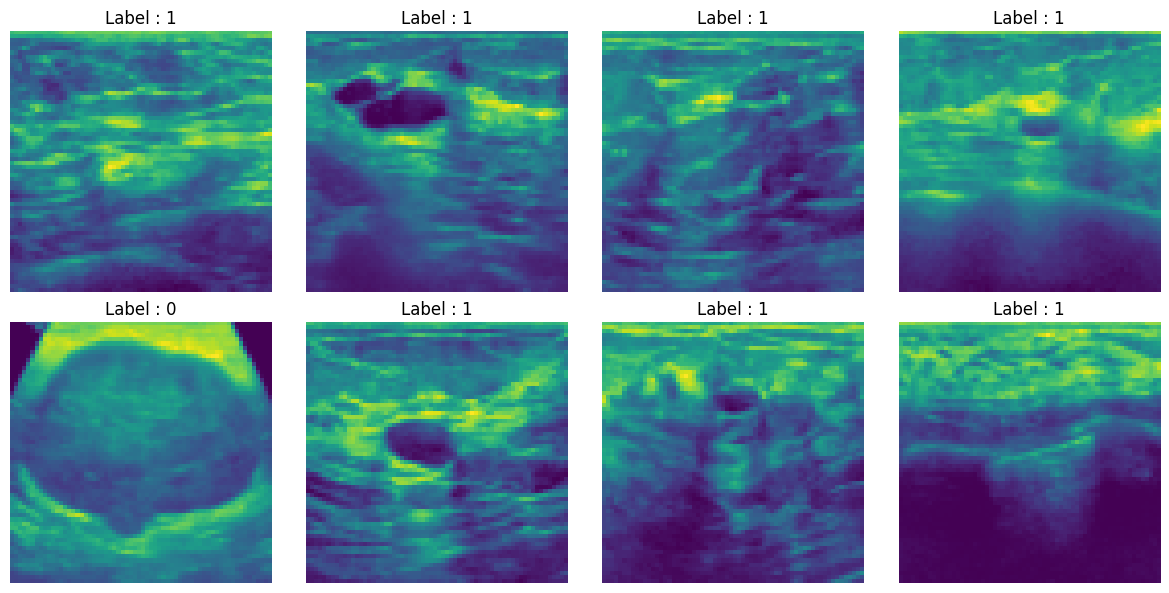

In [7]:
images = data["train_images"]
labels = data["train_labels"]

plt.figure(figsize=(12,6))

for i in range(8):
    
    plt.subplot(2,4,i+1)
    
    plt.imshow(images[i])
    plt.title(f"Label : {labels[i][0]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model: GoogleNet Model

In [9]:
from torchvision.models import googlenet, GoogLeNet_Weights

class GoogleNetModel(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = googlenet(
                weights=GoogLeNet_Weights.IMAGENET1K_V1
            )
        else:
            self.model = googlenet(weights=None)

        # Replace final classifier
        self.model.fc = nn.Linear(
            self.model.fc.in_features,
            num_classes
        )

    def forward(self, x):
        return self.model(x)

# Model: Resnet Family

In [10]:
from torchvision.models import resnet18, ResNet18_Weights

class ResNet18Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        else:
            self.model = resnet18(weights=None)

        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [11]:
from torchvision.models import resnet34, ResNet34_Weights

class ResNet34Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
        else:
            self.model = resnet34(weights=None)

        # Replace final classifier
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [12]:
from torchvision.models import resnet50, ResNet50_Weights

class ResNet50Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        else:
            self.model = resnet50(weights=None)

        # Replace final classifier
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [13]:
from torchvision.models import resnet101, ResNet101_Weights

class ResNet101Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = resnet101(weights=ResNet101_Weights.IMAGENET1K_V1)
        else:
            self.model = resnet101(weights=None)

        # Replace final classifier
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [14]:
from torchvision.models import resnet152, ResNet152_Weights

class ResNet152Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = resnet152(weights=ResNet152_Weights.IMAGENET1K_V1)
        else:
            self.model = resnet152(weights=None)

        # Replace final classifier
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [15]:
from torchvision.models import (efficientnet_b0, EfficientNet_B0_Weights)

class EfficientNetB0Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        else:
            self.model = efficientnet_b0(weights=None)
            
        in_features = self.model.classifier[1].in_features

        self.model.classifier[1] = nn.Linear(in_features,num_classes)

    def forward(self, x):
        return self.model(x)

In [25]:
from torchvision.models import (efficientnet_b1, EfficientNet_B1_Weights)

class EfficientNetB1Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = efficientnet_b1(weights=EfficientNet_B1_Weights.IMAGENET1K_V1)
        else:
            self.model = efficientnet_b1(weights=None)
            
        in_features = self.model.classifier[1].in_features

        self.model.classifier[1] = nn.Linear(in_features,num_classes)

    def forward(self, x):
        return self.model(x)

In [27]:
from torchvision.models import (efficientnet_b2, EfficientNet_B2_Weights)

class EfficientNetB2Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)
        else:
            self.model = efficientnet_b2(weights=None)
            
        in_features = self.model.classifier[1].in_features

        self.model.classifier[1] = nn.Linear(in_features,num_classes)

    def forward(self, x):
        return self.model(x)

In [29]:
from torchvision.models import (efficientnet_b3, EfficientNet_B3_Weights)

class EfficientNetB3Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        else:
            self.model = efficientnet_b3(weights=None)
            
        in_features = self.model.classifier[1].in_features

        self.model.classifier[1] = nn.Linear(in_features,num_classes)

    def forward(self, x):
        return self.model(x)

In [31]:
from torchvision.models import (efficientnet_b4, EfficientNet_B4_Weights)

class EfficientNetB4Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        else:
            self.model = efficientnet_b4(weights=None)
            
        in_features = self.model.classifier[1].in_features

        self.model.classifier[1] = nn.Linear(in_features,num_classes)

    def forward(self, x):
        return self.model(x)

In [33]:
from torchvision.models import (efficientnet_b5, EfficientNet_B5_Weights)

class EfficientNetB5Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = efficientnet_b5(weights=EfficientNet_B5_Weights.IMAGENET1K_V1)
        else:
            self.model = efficientnet_b5(weights=None)
            
        in_features = self.model.classifier[1].in_features

        self.model.classifier[1] = nn.Linear(in_features,num_classes)

    def forward(self, x):
        return self.model(x)

In [35]:
from torchvision.models import (efficientnet_b6, EfficientNet_B6_Weights)

class EfficientNetB6Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = efficientnet_b6(weights=EfficientNet_B6_Weights.IMAGENET1K_V1)
        else:
            self.model = efficientnet_b6(weights=None)
            
        in_features = self.model.classifier[1].in_features

        self.model.classifier[1] = nn.Linear(in_features,num_classes)

    def forward(self, x):
        return self.model(x)

In [37]:
from torchvision.models import (efficientnet_b7, EfficientNet_B7_Weights)

class EfficientNetB7Model(nn.Module):

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        if pretrained:
            self.model = efficientnet_b7(weights=EfficientNet_B7_Weights.IMAGENET1K_V1)
        else:
            self.model = efficientnet_b7(weights=None)
            
        in_features = self.model.classifier[1].in_features

        self.model.classifier[1] = nn.Linear(in_features,num_classes)

    def forward(self, x):
        return self.model(x)

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device :", device)

#model1 = GoogleNetModel(num_classes=2, pretrained=True)
#model2 = ResNet152Model(num_classes=2, pretrained=True)
model2= EfficientNetB7Model(num_classes=2, pretrained=True)

model2 = model2.to(device)

Using Device : cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth


100%|██████████| 255M/255M [00:01<00:00, 152MB/s]  


In [39]:
!pip install torchinfo

In [40]:
from torchinfo import summary

summary(model2, input_size=(1, 3, 64, 64), col_names=("input_size", "output_size", "num_params"))

Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #
EfficientNetB7Model                                          [1, 3, 64, 64]            [1, 2]                    --
├─EfficientNet: 1-1                                          [1, 3, 64, 64]            [1, 2]                    --
│    └─Sequential: 2-1                                       [1, 3, 64, 64]            [1, 2560, 2, 2]           --
│    │    └─Conv2dNormActivation: 3-1                        [1, 3, 64, 64]            [1, 64, 32, 32]           1,856
│    │    └─Sequential: 3-2                                  [1, 64, 32, 32]           [1, 32, 32, 32]           10,920
│    │    └─Sequential: 3-3                                  [1, 32, 32, 32]           [1, 48, 16, 16]           253,424
│    │    └─Sequential: 3-4                                  [1, 48, 16, 16]           [1, 80, 8, 8]             716,068
│    │    └─Sequential: 3-5                       

In [41]:
!pip install thop

In [42]:
from thop import profile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dummy = torch.randn(1, 3, 64, 64).to(device)
flops, params = profile(model2, inputs=(dummy,))

print(f"FLOPs : {flops/1e9:.3f} GFLOPs")
print(f"Params: {params/1e6:.3f} M")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
FLOPs : 0.447 GFLOPs
Params: 63.792 M


In [21]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model2.parameters(),lr=0.001)

In [22]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        current_acc = 100 * correct / total

        # Update tqdm bar
        progress_bar.set_postfix(loss=loss.item(), acc=current_acc)

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [23]:
def evaluate(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():

        for images, labels in progress_bar:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            current_acc = 100 * correct / total

            progress_bar.set_postfix(loss=loss.item(), acc=current_acc)

    epoch_loss = running_loss / len(loader)

    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [24]:
num_epochs = 5

train_losses = []
val_losses = []

train_accs = []
val_accs = []


for epoch in range(num_epochs):

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss:{train_loss:.4f}, Train Acc:{train_acc:.2f}%, Val Loss:{val_loss:.4f}, Val Acc:{val_acc:.2f}%")


Epoch [1/5]


NameError: name 'model' is not defined

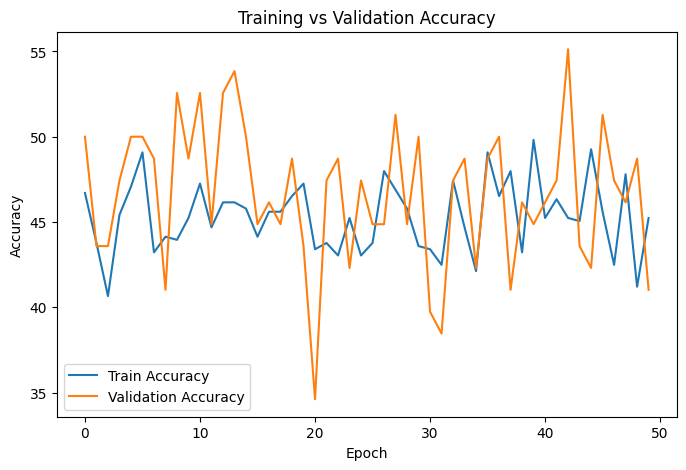

In [37]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

In [38]:
test_loss, test_acc = evaluate(model, test_loader)

print(f"Test Accuracy : {test_acc:.2f}%")

Test Accuracy : 43.59%


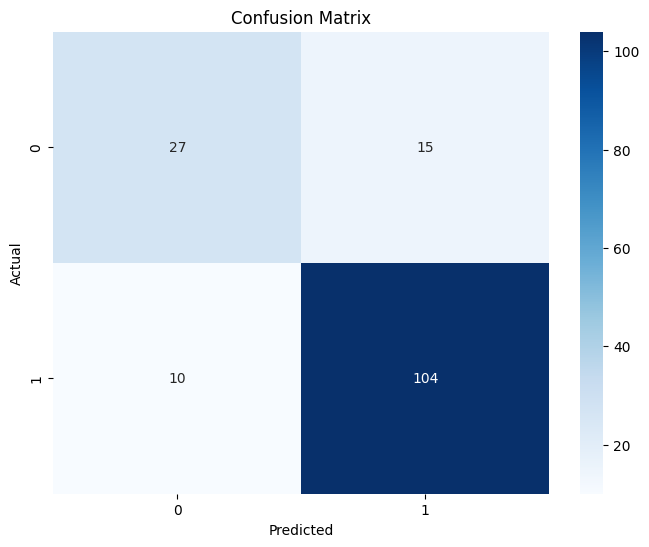

In [34]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(all_labels, all_preds))

In [ ]:
torch.save(model.state_dict(), "bloodmnist_cnn.pth")

print("Model Saved Successfully!")